<a href="https://colab.research.google.com/github/irenetobby/Exit_exam/blob/main/Bengaluru_house_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_csv('/content/Bengaluru_House_Data.csv')

In [ ]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
None


In [ ]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [ ]:
print(df.shape)
print(df.columns)

(13320, 9)
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')


DATA CLEANING

In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


Fix inconsistent formats

In [ ]:
def convert_sqft(x):
    try:
        if '-' in x:
            a, b = x.split('-')
            return (float(a) + float(b)) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [ ]:
df2 = df.drop('society', axis='columns')

In [ ]:
df3 = df2.dropna(subset=['location', 'size'])

In [ ]:
df3.loc[:, 'bath'] = df3['bath'].fillna(df3['bath'].median())

In [ ]:
# Check if the rows are back and if the nulls are gone
print("New Shape:", df3.shape)
print("\nMissing values remaining:")
print(df3.isnull().sum())

New Shape: (13303, 8)

Missing values remaining:
area_type         0
availability      0
location          0
size              0
total_sqft        0
bath              0
balcony         593
price             0
dtype: int64


Exploratory Data Analysis (EDA)

Univariate Analysis

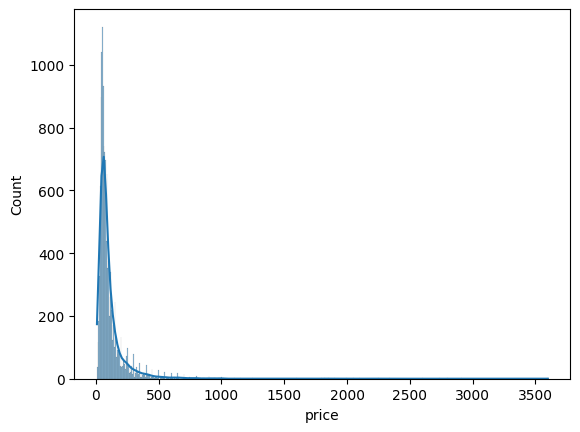

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['price'], kde=True)
plt.show()



In [ ]:
# Create a 'bhk' column from 'size' if you haven't yet
df3.loc[:, 'bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

# Ensure 'total_sqft' is numeric before division
df3.loc[:, 'total_sqft'] = pd.to_numeric(df3['total_sqft'], errors='coerce')

# Filter out rows where area per bedroom is less than 300 sqft
df5 = df3[~(df3.total_sqft / df3.bhk < 300)]

print("Shape after BHK outlier removal:", df5.shape)

Shape after BHK outlier removal: (12559, 9)


In [ ]:
# Filter out properties where bathrooms are more than BHK + 2
df6 = df5[df5.bath < df5.bhk + 2]

print("Shape after Bathroom outlier removal:", df6.shape)

Shape after Bathroom outlier removal: (12406, 9)


In [ ]:
# 1. Simplify locations (group rare locations into 'other')
location_stats = df6.groupby('location')['location'].agg('count').sort_values(ascending=False)
locations_less_than_10 = location_stats[location_stats <= 10]
df6.location = df6.location.apply(lambda x: 'other' if x in locations_less_than_10 else x)

# 2. Create dummies
dummies = pd.get_dummies(df6.location)

# 3. Concatenate and drop original location & 'other' column
df7 = pd.concat([df6, dummies.drop('other', axis='columns')], axis='columns')
df8 = df7.drop('location', axis='columns')

print("Final Dataframe shape ready for ML:", df8.shape)

Final Dataframe shape ready for ML: (12406, 231)


/tmp/ipykernel_3722/1436922248.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df6.location = df6.location.apply(lambda x: 'other' if x in locations_less_than_10 else x)


Bivariate analysis

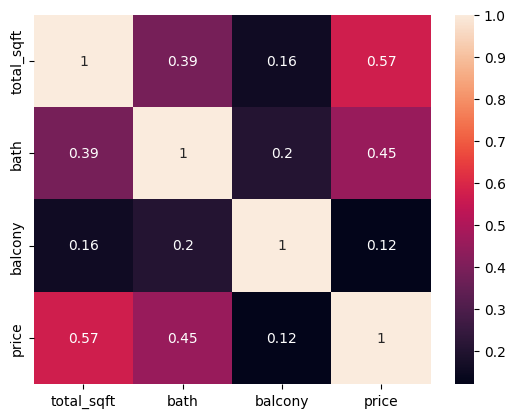

In [ ]:
# Create a subset of the DataFrame with the relevant columns
df3_corr_subset = df3[['total_sqft', 'bath', 'balcony', 'price']].copy()

# Ensure 'total_sqft' is numeric, coercing any errors to NaN
df3_corr_subset['total_sqft'] = pd.to_numeric(df3_corr_subset['total_sqft'], errors='coerce')

# Calculate and plot the correlation heatmap
sns.heatmap(df3_corr_subset.corr(), annot=True)
plt.show()

In [ ]:
# 1. Calculate Q1, Q3, and IQR for the 'price' column
Q1 = df3['price'].quantile(0.25)
Q3 = df3['price'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter the data
df_clean = df3[(df3['price'] >= lower_bound) & (df3['price'] <= upper_bound)]

# 4. Compare the results
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print("Original shape:", df3.shape)
print("Shape after removing price outliers:", df_clean.shape)

Lower Bound: -55.0, Upper Bound: 225.0
Original shape: (13303, 8)
Shape after removing price outliers: (12029, 8)


Feature Engineering

In [ ]:
# Create price_per_sqft feature
df6.loc[:, 'price_per_sqft'] = df6['price'] * 100000 / df6['total_sqft']

print(df6.head())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   total_sqft  bath  balcony   price  bhk  price_per_sqft  
0      1056.0   2.0      1.0   39.07    2     3699.810606  
1      2600.0   5.0      3.0  120.00    4     4615.384615  
2      1440.0   2.0      3.0   62.00    3     4305.555556  
3      1521.0   3.0      1.0   95.00    3     6245.890861  
4      1200.0   2.0      1.0   51.00    2     4250.000000  


In [ ]:
# Clean up location: group locations with few entries into 'other'
df4 = df3.copy()
df4.location = df4.location.apply(lambda x: x.strip())
location_stats = df4.groupby('location')['location'].agg('count').sort_values(ascending=False)

# Identify locations with 10 or fewer data points
locations_less_than_10 = location_stats[location_stats <= 10]

# Replace them with 'other'
df4.location = df4.location.apply(lambda x: 'other' if x in locations_less_than_10 else x)

print("Unique locations after cleaning:", len(df4.location.unique()))

Unique locations after cleaning: 242


In [ ]:
# Create dummy variables for location
dummies = pd.get_dummies(df4.location)

# Concatenate with the main dataframe and drop the original location column
df5 = pd.concat([df4, dummies.drop('other', axis='columns')], axis='columns')
df5 = df5.drop('location', axis='columns')

print("New shape after encoding:", df5.shape)

New shape after encoding: (13303, 249)


Handling outliers

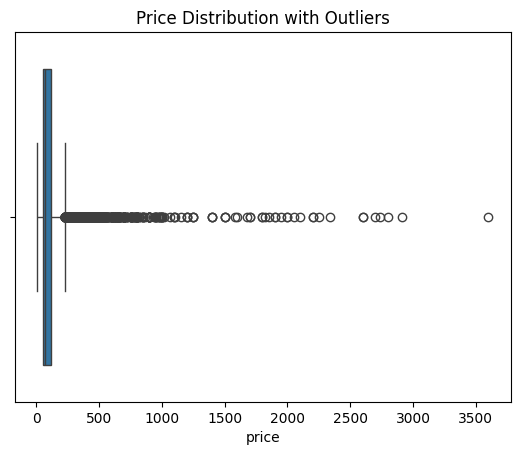

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df3['price'])
plt.title("Price Distribution with Outliers")
plt.show()

In [ ]:
# Calculating IQR
Q1 = df3['price'].quantile(0.25)
Q3 = df3['price'].quantile(0.75)
IQR = Q3 - Q1

# Defining the limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Lower Limit: {lower_limit}")
print(f"Upper Limit: {upper_limit}")

Lower Limit: -55.0
Upper Limit: 225.0


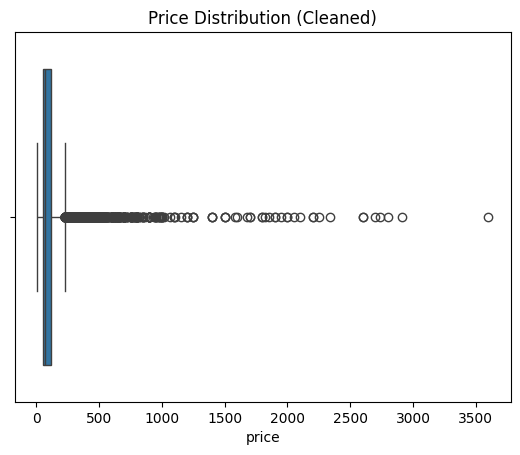

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df4['price'])
plt.title("Price Distribution (Cleaned)")
plt.show()

In [ ]:
# Drop any remaining rows that have a NaN in any column
df8 = df8.dropna()

In [ ]:
df8['balcony'] = df8['balcony'].fillna(df8['balcony'].median())

Define X and y

In [ ]:
# X contains the features, y contains the target price
# First, one-hot encode the remaining categorical columns
df9 = pd.get_dummies(df8, columns=['area_type', 'availability'], drop_first=True)

# Drop 'price' (target variable) and 'size' (replaced by 'bhk') from features
X = df9.drop(['price', 'size'], axis='columns')
y = df9.price

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (11752, 307)
Target (y) shape: (11752,)


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 9401
Testing set size: 2351


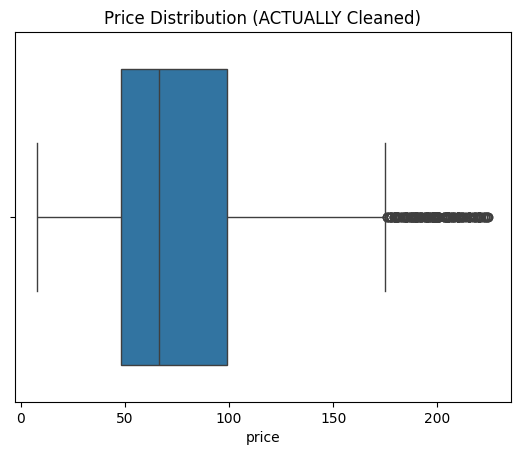

Old count: 13303, New count: 11987


In [ ]:
# 1. Re-calculate limits (just to be sure)
Q1 = df3['price'].quantile(0.25)
Q3 = df3['price'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# 2. CREATE THE CLEANED DATAFRAME
# Make sure you are assigning it to a NEW variable name
df_final_clean = df3[(df3['price'] > lower_limit) & (df3['price'] < upper_limit)]

# 3. PLOT THE NEW VARIABLE
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_final_clean['price'])
plt.title("Price Distribution (ACTUALLY Cleaned)")
plt.show()

print(f"Old count: {len(df3)}, New count: {len(df_final_clean)}")

Model Evaluation

In [ ]:
from sklearn.linear_model import LinearRegression

lr_clf = LinearRegression()
lr_clf.fit(X_train, y_train)

# Calculate the R-squared score
score = lr_clf.score(X_test, y_test)
print(f"Model Accuracy (R-squared): {score * 100:.2f}%")

Model Accuracy (R-squared): 39.74%


K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

# Shuffling the data ensures a random distribution
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

results = cross_val_score(LinearRegression(), X, y, cv=cv)
print("Cross-validation scores:", results)
print(f"Average Accuracy: {results.mean() * 100:.2f}%")

Cross-validation scores: [0.50419439 0.40052998 0.5863494  0.3977989  0.27482753]
Average Accuracy: 43.27%
